# 03 — Feature Engineering

**Goal:** Create all features driven by EDA findings. Validate every feature before adding it.

> ✅ We only work on **train data** here. Features are created, validated, then turned into a reusable custom transformer.

**Feature groups:**
1. Calendar features — hour, dow, month, season, is_weekend, is_holiday
2. Cyclical encoding — sin/cos transforms for periodic features
3. Lag features — demand 1h, 24h, 48h, 168h, 336h ago
4. Rolling window features — mean and std over past 24h and 168h
5. Weather interaction features — temp², is_cold, is_hot
6. Validation — correlation, VIF, no leakage
7. Custom transformer class

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
PROCESSED_PATH = '../data/processed/'
TARGET = 'total load actual'

## 1. Load Train Data

In [2]:
train = pd.read_csv(PROCESSED_PATH + 'train.csv')
train['time'] = pd.to_datetime(train['time'], utc=True)
train = train.sort_values('time').reset_index(drop=True)

print(f'Shape: {train.shape}')
train.head(3)

Shape: (24544, 32)


,time,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,...,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all
0,2014-12-31 23:00:00+00:00,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,7096.0,...,272.491463,272.491463,1016.4,82.4,2.0,135.2,0.0,0.0,0.0,0.0
1,2015-01-01 00:00:00+00:00,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,7096.0,...,272.512700,272.512700,1016.2,82.4,2.0,135.8,0.0,0.0,0.0,0.0
2,2015-01-01 01:00:00+00:00,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,7099.0,...,272.099137,272.099137,1016.8,82.0,2.4,119.0,0.0,0.0,0.0,0.0


## 2. Calendar Features

In [3]:
def add_calendar_features(df):
    """
    Add time-based calendar features from the 'time' timestamp column.
    All features are derived purely from the timestamp — no leakage.
    """
    df = df.copy()
    t = df['time']

    df['hour']        = t.dt.hour                          # 0–23
    df['dow']         = t.dt.dayofweek                     # 0=Mon, 6=Sun
    df['month']       = t.dt.month                         # 1–12
    df['day_of_year'] = t.dt.dayofyear                     # 1–365
    df['week_of_year']= t.dt.isocalendar().week.astype(int)
    df['quarter']     = t.dt.quarter                       # 1–4
    df['is_weekend']  = (t.dt.dayofweek >= 5).astype(int)  # 0 or 1

    # Season: 0=Spring, 1=Summer, 2=Autumn, 3=Winter
    month_to_season = {12:3, 1:3, 2:3,   # Winter
                       3:0,  4:0, 5:0,   # Spring
                       6:1,  7:1, 8:1,   # Summer
                       9:2, 10:2, 11:2}  # Autumn
    df['season'] = df['month'].map(month_to_season)

    # Spain public holidays (approximate — main ones)
    # For production: use the 'holidays' library: pip install holidays
    try:
        import holidays
        es_holidays = holidays.Spain(years=range(2015, 2020))
        df['is_holiday'] = t.dt.date.astype(str).map(
            lambda d: 1 if d in [str(h) for h in es_holidays] else 0
        )
    except ImportError:
        # Fallback: Christmas, New Year, Easter approximate dates
        holiday_dates = [
            '2015-01-01','2015-12-25','2016-01-01','2016-12-25',
            '2017-01-01','2017-12-25','2018-01-01','2018-12-25'
        ]
        df['is_holiday'] = t.dt.date.astype(str).isin(holiday_dates).astype(int)
        print('⚠️  holidays library not installed. Using minimal holiday list.')
        print('   Install with: pip install holidays')

    return df

df = add_calendar_features(train)
new_cols = ['hour','dow','month','day_of_year','week_of_year','quarter','is_weekend','season','is_holiday']
print('Calendar features added:')
print(df[new_cols].describe().T[['mean','min','max']].round(2).to_string())

⚠️  holidays library not installed. Using minimal holiday list.
   Install with: pip install holidays
Calendar features added:
                mean  min    max
hour           11.50  0.0   23.0
dow             3.00  0.0    6.0
month           6.18  1.0   12.0
day_of_year   172.72  1.0  366.0
week_of_year   25.27  1.0   53.0
quarter         2.40  1.0    4.0
is_weekend      0.29  0.0    1.0
season          1.43  0.0    3.0
is_holiday      0.00  0.0    1.0


## 3. Cyclical Encoding

Hour 23 and hour 0 are adjacent (11pm → midnight) but numerically far apart (23 vs 0).  
Raw integers can't express this continuity. Sin/cos encoding wraps the circle correctly.

```
sin_hour = sin(2π × hour / 24)
cos_hour = cos(2π × hour / 24)
```

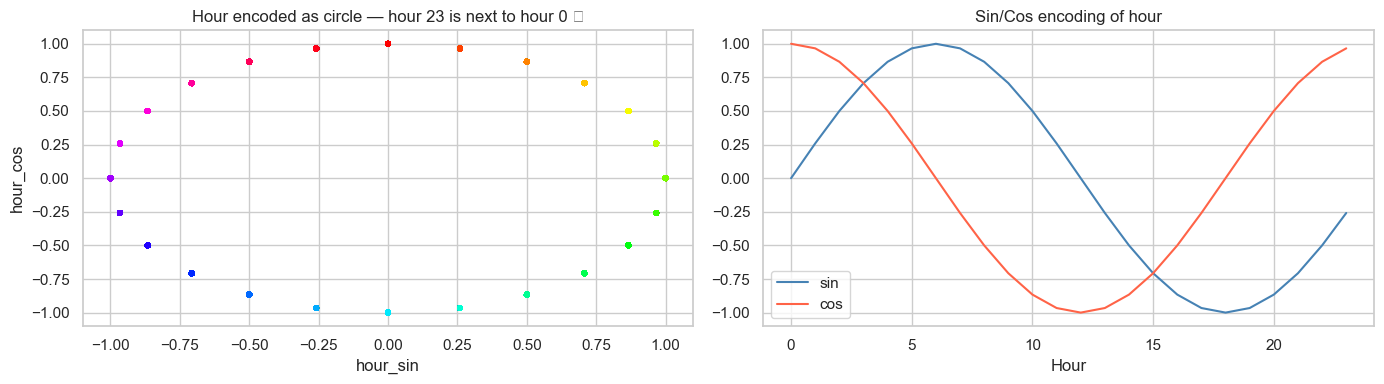

In [4]:
def add_cyclical_features(df):
    """
    Encode periodic features using sin/cos so that
    hour 23 and hour 0 are numerically close.
    """
    df = df.copy()

    # Hour of day (period = 24)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    # Day of week (period = 7)
    df['dow_sin']  = np.sin(2 * np.pi * df['dow'] / 7)
    df['dow_cos']  = np.cos(2 * np.pi * df['dow'] / 7)

    # Month (period = 12)
    df['month_sin']= np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']= np.cos(2 * np.pi * df['month'] / 12)

    # Day of year (period = 365)
    df['doy_sin']  = np.sin(2 * np.pi * df['day_of_year'] / 365)
    df['doy_cos']  = np.cos(2 * np.pi * df['day_of_year'] / 365)

    return df

df = add_cyclical_features(df)

# Visualize: hour_sin + hour_cos together encode the full 24h cycle
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(df['hour_sin'], df['hour_cos'], c=df['hour'], cmap='hsv', s=10, alpha=0.5)
axes[0].set_title('Hour encoded as circle — hour 23 is next to hour 0 ✅')
axes[0].set_xlabel('hour_sin')
axes[0].set_ylabel('hour_cos')

hours = range(24)
axes[1].plot(hours, np.sin(2*np.pi*np.array(hours)/24), label='sin', color='steelblue')
axes[1].plot(hours, np.cos(2*np.pi*np.array(hours)/24), label='cos', color='tomato')
axes[1].set_title('Sin/Cos encoding of hour')
axes[1].set_xlabel('Hour')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Lag Features

> **Critical rule:** `shift(n)` where n > 0 looks **backward** (past data). Never use negative shift.
> `lag_24h` at row index i equals `target[i - 24]` — always verified below.

In [5]:
def add_lag_features(df, target_col='total load actual',
                     lag_hours=[1, 24, 48, 168, 336]):
    """
    Add lag features: demand N hours ago.
    
    shift(n) with n > 0 shifts DOWN — values from the past.
    df['lag_24h'][i] == df[target_col][i-24]  ← past data, no leakage.
    """
    df = df.copy()
    for lag in lag_hours:
        df[f'lag_{lag}h'] = df[target_col].shift(lag)
    return df

df = add_lag_features(df)

# ── Verify no leakage ──────────────────────────────────────
# lag_24h at row 100 must equal target at row 76 (100 - 24)
for lag in [1, 24, 48, 168, 336]:
    idx = 500  # arbitrary row well past the initial NaN window
    expected = df[TARGET].iloc[idx - lag]
    actual   = df[f'lag_{lag}h'].iloc[idx]
    match    = '✅' if np.isclose(expected, actual) else '❌ LEAKAGE!'
    print(f'lag_{lag}h: expected {expected:,.1f}  got {actual:,.1f}  {match}')

print()
print('NaN rows introduced by lag features:')
for lag in [1, 24, 48, 168, 336]:
    n_nan = df[f'lag_{lag}h'].isnull().sum()
    print(f'  lag_{lag}h: {n_nan} NaN rows (first {lag} rows of dataset)')

lag_1h: expected 40,081.0  got 40,081.0  ✅
lag_24h: expected 40,207.0  got 40,207.0  ✅
lag_48h: expected 39,262.0  got 39,262.0  ✅
lag_168h: expected 37,633.0  got 37,633.0  ✅
lag_336h: expected 34,470.0  got 34,470.0  ✅

NaN rows introduced by lag features:
  lag_1h: 1 NaN rows (first 1 rows of dataset)
  lag_24h: 24 NaN rows (first 24 rows of dataset)
  lag_48h: 48 NaN rows (first 48 rows of dataset)
  lag_168h: 168 NaN rows (first 168 rows of dataset)
  lag_336h: 336 NaN rows (first 336 rows of dataset)


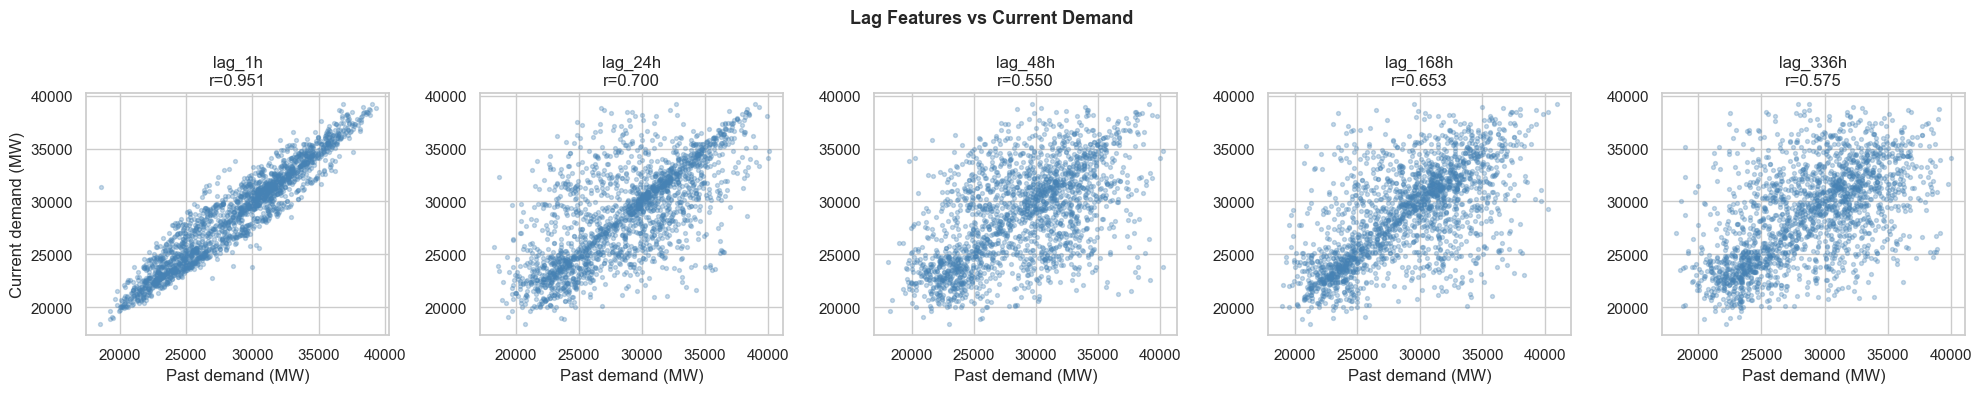

In [6]:
# Visualize lag correlations
lag_cols = [f'lag_{l}h' for l in [1, 24, 48, 168, 336]]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

sample = df.dropna().sample(2000, random_state=42)
for i, col in enumerate(lag_cols):
    r = df[col].corr(df[TARGET])
    axes[i].scatter(sample[col], sample[TARGET], alpha=0.3, s=8, color='steelblue')
    axes[i].set_title(f'{col}\nr={r:.3f}')
    axes[i].set_xlabel('Past demand (MW)')
    if i == 0: axes[i].set_ylabel('Current demand (MW)')

plt.suptitle('Lag Features vs Current Demand', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Rolling Window Features

In [7]:
def add_rolling_features(df, target_col='total load actual'):
    """
    Add rolling statistics. 
    
    CRITICAL: we shift(1) BEFORE rolling to exclude the current row.
    This ensures rolling_mean_24h at time T uses only hours T-1 through T-24.
    Without shift(1), the window would include time T itself — leakage!
    """
    df = df.copy()

    # Shift first: exclude current row from all rolling calculations
    shifted = df[target_col].shift(1)

    df['rolling_mean_24h']  = shifted.rolling(window=24,  min_periods=12).mean()
    df['rolling_mean_168h'] = shifted.rolling(window=168, min_periods=84).mean()
    df['rolling_std_24h']   = shifted.rolling(window=24,  min_periods=12).std()
    df['rolling_max_24h']   = shifted.rolling(window=24,  min_periods=12).max()
    df['rolling_min_24h']   = shifted.rolling(window=24,  min_periods=12).min()

    return df

df = add_rolling_features(df)

rolling_cols = ['rolling_mean_24h','rolling_mean_168h','rolling_std_24h','rolling_max_24h','rolling_min_24h']
print('Rolling features correlation with target:')
for col in rolling_cols:
    r = df[col].corr(df[TARGET])
    print(f'  {col:25s}: {r:.4f}')

Rolling features correlation with target:
  rolling_mean_24h         : 0.4582
  rolling_mean_168h        : 0.2594
  rolling_std_24h          : 0.2695
  rolling_max_24h          : 0.4975
  rolling_min_24h          : 0.5242


## 6. Weather Interaction Features

In [8]:
def add_weather_features(df):
    """
    Create engineered weather features from EDA findings:
    - temp² captures U-shaped relationship
    - is_cold / is_hot binary flags
    - is_raining binary flag
    """
    df = df.copy()

    # Temperature in Kelvin in this dataset
    # Cold = below 7°C (280K), Hot = above 25°C (298K)
    df['temp_squared'] = df['temp'] ** 2
    df['is_cold']      = (df['temp'] < 280).astype(int)
    df['is_hot']       = (df['temp'] > 298).astype(int)

    # Felt temperature approximation
    df['temp_humidity'] = df['temp'] * df['humidity'] / 100

    # Rain flag
    df['is_raining']   = (df['rain_1h'] > 0).astype(int)

    # Wind chill approximation (high wind + cold = more heating demand)
    df['wind_chill']   = df['wind_speed'] * (1 - df['temp'] / 310)

    return df

df = add_weather_features(df)

weather_eng_cols = ['temp_squared','is_cold','is_hot','temp_humidity','is_raining','wind_chill']
print('Engineered weather features correlation with target:')
for col in weather_eng_cols:
    r = df[col].corr(df[TARGET])
    print(f'  {col:20s}: {r:.4f}')

Engineered weather features correlation with target:
  temp_squared        : 0.2363
  is_cold             : -0.0902
  is_hot              : 0.2800
  temp_humidity       : -0.3651
  is_raining          : 0.0075
  wind_chill          : 0.0395


## 7. Validation — Correlation, VIF, No Leakage

In [9]:
# Final feature set after dropping NaN rows from lags
df_clean = df.dropna().reset_index(drop=True)

# Define final feature groups
CALENDAR_FEATURES = ['hour','dow','month','quarter','is_weekend','season','is_holiday']
CYCLICAL_FEATURES = ['hour_sin','hour_cos','dow_sin','dow_cos','month_sin','month_cos','doy_sin','doy_cos']
LAG_FEATURES      = ['lag_1h','lag_24h','lag_48h','lag_168h','lag_336h']
ROLLING_FEATURES  = ['rolling_mean_24h','rolling_mean_168h','rolling_std_24h','rolling_max_24h','rolling_min_24h']
WEATHER_ORIG      = ['temp','humidity','wind_speed','wind_deg','clouds_all','pressure','rain_1h','snow_3h']
WEATHER_ENG       = ['temp_squared','is_cold','is_hot','temp_humidity','is_raining','wind_chill']
LOAD_FORECAST     = ['total load forecast']  # available ahead of time — keep!

ALL_FEATURES = (CALENDAR_FEATURES + CYCLICAL_FEATURES + LAG_FEATURES +
                ROLLING_FEATURES + WEATHER_ORIG + WEATHER_ENG + LOAD_FORECAST)

print(f'Total features: {len(ALL_FEATURES)}')
print(f'Train rows after dropna: {len(df_clean):,}  (was {len(df):,})')
print(f'Rows removed by lag NaN: {len(df) - len(df_clean):,}  (first 336 rows)')

Total features: 40
Train rows after dropna: 24,208  (was 24,544)
Rows removed by lag NaN: 336  (first 336 rows)


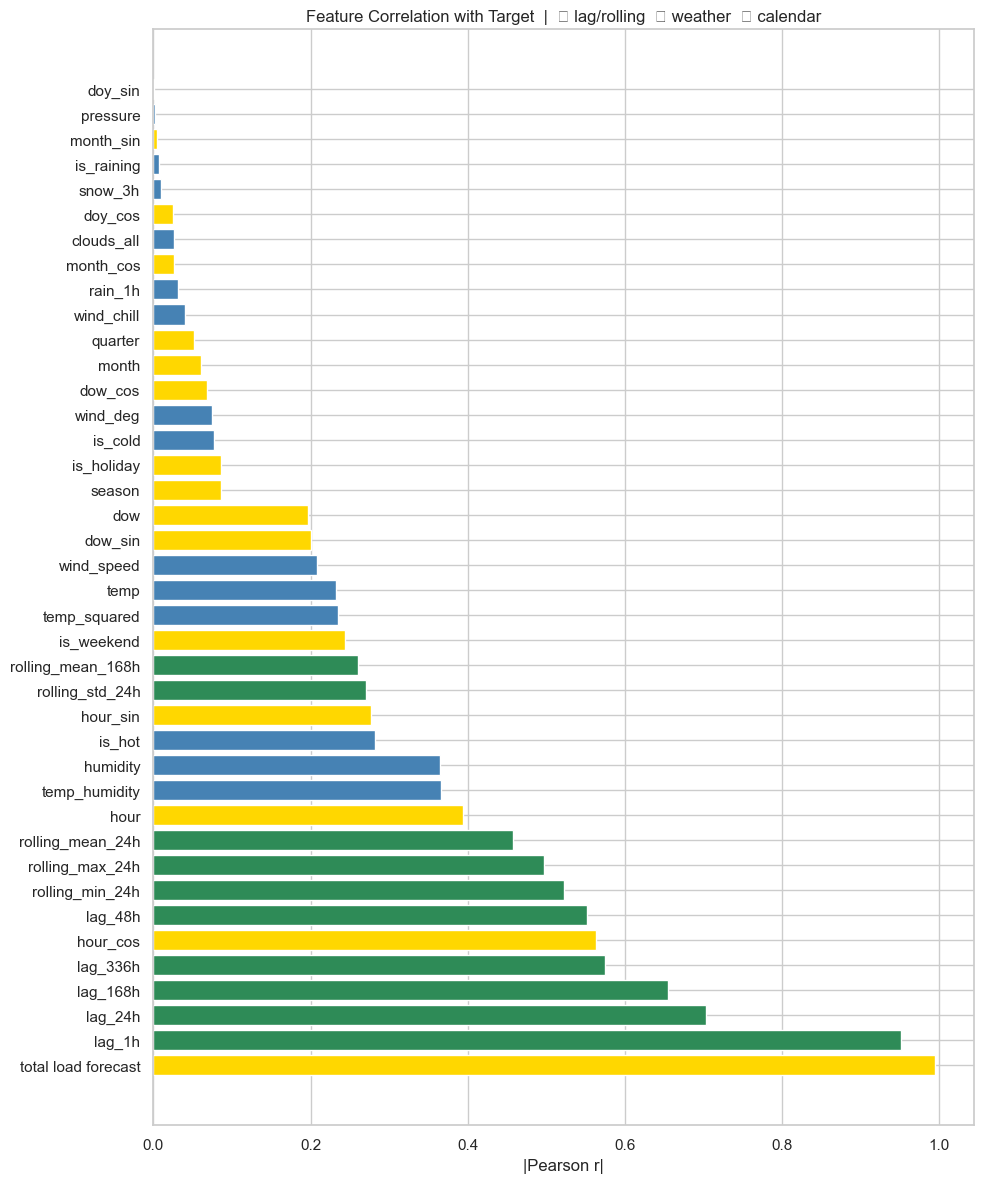

Top 10 features:
total load forecast    0.9946
lag_1h                 0.9508
lag_24h                0.7026
lag_168h               0.6550
lag_336h               0.5751
hour_cos               0.5635
lag_48h                0.5517
rolling_min_24h        0.5224
rolling_max_24h        0.4975
rolling_mean_24h       0.4579


In [10]:
# All features correlation with target
feat_corr = df_clean[ALL_FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['seagreen' if f in LAG_FEATURES + ROLLING_FEATURES
          else 'steelblue' if f in WEATHER_ORIG + WEATHER_ENG
          else 'gold' for f in feat_corr.index]
ax.barh(feat_corr.index, feat_corr.values, color=colors, edgecolor='white')
ax.set_title('Feature Correlation with Target  |  🟩 lag/rolling  🟦 weather  🟨 calendar')
ax.set_xlabel('|Pearson r|')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(feat_corr.head(10).round(4).to_string())

In [11]:
# VIF check on numeric features
# Note: lag features and rolling features will naturally have high VIF
# Tree models handle this fine; we flag extreme cases only

numeric_feats_for_vif = LAG_FEATURES + ROLLING_FEATURES + WEATHER_ORIG + WEATHER_ENG
vif_df = df_clean[numeric_feats_for_vif].dropna()

vif_results = pd.DataFrame({
    'Feature': vif_df.columns,
    'VIF': [variance_inflation_factor(vif_df.values, i)
            for i in range(vif_df.shape[1])]
}).sort_values('VIF', ascending=False)

print('VIF Results (VIF > 10 = high multicollinearity):')
for _, row in vif_results.iterrows():
    flag = '🔴 HIGH' if row['VIF'] > 10 else ('🟡 MOD' if row['VIF'] > 5 else '🟢 OK')
    print(f"  {row['Feature']:30s}: {row['VIF']:8.2f}  {flag}")

print()
print('Decision: High VIF in lag/rolling features is expected — they measure the same')
print('underlying quantity at different time offsets. Tree models handle this fine.')
print('For Ridge (linear baseline), regularization handles the multicollinearity.')

VIF Results (VIF > 10 = high multicollinearity):
  temp                          : 98388.16  🔴 HIGH
  temp_squared                  : 96732.18  🔴 HIGH
  humidity                      : 64076.36  🔴 HIGH
  temp_humidity                 : 63510.85  🔴 HIGH
  rolling_min_24h               :  3069.51  🔴 HIGH
  rolling_max_24h               :  2753.57  🔴 HIGH
  rolling_mean_24h              :  2581.75  🔴 HIGH
  rolling_mean_168h             :   758.42  🔴 HIGH
  rolling_std_24h               :   325.46  🔴 HIGH
  lag_24h                       :   157.66  🔴 HIGH
  lag_1h                        :   127.69  🔴 HIGH
  lag_48h                       :   114.77  🔴 HIGH
  lag_168h                      :   104.60  🔴 HIGH
  lag_336h                      :    86.76  🔴 HIGH
  wind_speed                    :    60.12  🔴 HIGH
  wind_chill                    :    54.43  🔴 HIGH
  wind_deg                      :    11.32  🔴 HIGH
  clouds_all                    :     5.19  🟡 MOD
  is_hot                        : 

In [12]:
# Drop low-value features based on analysis
LOW_CORR_THRESHOLD = 0.03  # below 3% correlation with target
low_corr_features = feat_corr[feat_corr < LOW_CORR_THRESHOLD].index.tolist()

print(f'Features below correlation threshold ({LOW_CORR_THRESHOLD}):')
if low_corr_features:
    for f in low_corr_features:
        print(f'  {f}: {feat_corr[f]:.4f}')
    print('  → Consider dropping these in the pipeline')
else:
    print('  None — all features pass the threshold ✅')

Features below correlation threshold (0.03):
  month_cos: 0.0261
  clouds_all: 0.0258
  doy_cos: 0.0245
  snow_3h: 0.0101
  is_raining: 0.0069
  month_sin: 0.0047
  pressure: 0.0020
  doy_sin: 0.0012
  → Consider dropping these in the pipeline


## 8. Custom Transformer Class

Everything above goes into one class that fits into a sklearn Pipeline.

In [13]:
class EnergyFeatureTransformer(BaseEstimator, TransformerMixin):
    """
    Full feature engineering pipeline for energy demand prediction.
    
    Transforms raw merged dataframe (energy + weather) into model-ready features.
    
    Input:  DataFrame with 'time', 'total load actual', weather cols
    Output: DataFrame with all engineered features, NaN rows dropped
    
    Parameters
    ----------
    lag_hours : list of int
        Which lag hours to compute. Default: [1, 24, 48, 168, 336]
    add_cyclical : bool
        Whether to add sin/cos cyclical features. Default: True
    """

    def __init__(self, lag_hours=None, add_cyclical=True):
        self.lag_hours    = lag_hours or [1, 24, 48, 168, 336]
        self.add_cyclical = add_cyclical

    def fit(self, X, y=None):
        # Stateless — nothing to learn from training data
        # All transformations are deterministic from the data itself
        return self

    def transform(self, X):
        df = X.copy()  # NEVER modify original

        # Step 1: Parse time column
        df['time'] = pd.to_datetime(df['time'], utc=True)
        df = df.sort_values('time').reset_index(drop=True)

        # Step 2: Calendar features
        df = self._add_calendar(df)

        # Step 3: Cyclical encoding
        if self.add_cyclical:
            df = self._add_cyclical(df)

        # Step 4: Lag features
        df = self._add_lags(df)

        # Step 5: Rolling features
        df = self._add_rolling(df)

        # Step 6: Weather interactions
        df = self._add_weather(df)

        # Step 7: Drop rows with NaN from lags
        df = df.dropna().reset_index(drop=True)

        return df

    # ── Private helpers ──────────────────────────────────────

    def _add_calendar(self, df):
        t = df['time']
        df['hour']        = t.dt.hour
        df['dow']         = t.dt.dayofweek
        df['month']       = t.dt.month
        df['day_of_year'] = t.dt.dayofyear
        df['week_of_year']= t.dt.isocalendar().week.astype(int)
        df['quarter']     = t.dt.quarter
        df['is_weekend']  = (t.dt.dayofweek >= 5).astype(int)
        month_to_season   = {12:3,1:3,2:3, 3:0,4:0,5:0, 6:1,7:1,8:1, 9:2,10:2,11:2}
        df['season']      = df['month'].map(month_to_season)
        try:
            import holidays
            es_holidays = holidays.Spain(years=range(2015, 2020))
            df['is_holiday'] = t.dt.date.astype(str).map(
                lambda d: 1 if d in [str(h) for h in es_holidays] else 0
            )
        except ImportError:
            df['is_holiday'] = 0
        return df

    def _add_cyclical(self, df):
        df['hour_sin']  = np.sin(2*np.pi*df['hour']/24)
        df['hour_cos']  = np.cos(2*np.pi*df['hour']/24)
        df['dow_sin']   = np.sin(2*np.pi*df['dow']/7)
        df['dow_cos']   = np.cos(2*np.pi*df['dow']/7)
        df['month_sin'] = np.sin(2*np.pi*df['month']/12)
        df['month_cos'] = np.cos(2*np.pi*df['month']/12)
        df['doy_sin']   = np.sin(2*np.pi*df['day_of_year']/365)
        df['doy_cos']   = np.cos(2*np.pi*df['day_of_year']/365)
        return df

    def _add_lags(self, df):
        for lag in self.lag_hours:
            df[f'lag_{lag}h'] = df['total load actual'].shift(lag)
        return df

    def _add_rolling(self, df):
        shifted = df['total load actual'].shift(1)
        df['rolling_mean_24h']  = shifted.rolling(24,  min_periods=12).mean()
        df['rolling_mean_168h'] = shifted.rolling(168, min_periods=84).mean()
        df['rolling_std_24h']   = shifted.rolling(24,  min_periods=12).std()
        df['rolling_max_24h']   = shifted.rolling(24,  min_periods=12).max()
        df['rolling_min_24h']   = shifted.rolling(24,  min_periods=12).min()
        return df

    def _add_weather(self, df):
        df['temp_squared']  = df['temp'] ** 2
        df['is_cold']       = (df['temp'] < 280).astype(int)
        df['is_hot']        = (df['temp'] > 298).astype(int)
        df['temp_humidity'] = df['temp'] * df['humidity'] / 100
        df['is_raining']    = (df['rain_1h'] > 0).astype(int)
        df['wind_chill']    = df['wind_speed'] * (1 - df['temp'] / 310)
        return df

print('EnergyFeatureTransformer defined ✅')

EnergyFeatureTransformer defined ✅


In [14]:
# Test the transformer end-to-end
transformer = EnergyFeatureTransformer()
train_transformed = transformer.fit_transform(train)

print('✅ Transformer works!')
print(f'Input shape:  {train.shape}')
print(f'Output shape: {train_transformed.shape}')
print(f'New columns:  {train_transformed.shape[1] - train.shape[1]}')
print(f'Rows removed (lag NaN): {train.shape[0] - train_transformed.shape[0]}')
print()
print('Sample of new columns:')
print(train_transformed[['time','hour','hour_sin','lag_24h','rolling_mean_24h','temp_squared','is_cold']].head(5).to_string())

✅ Transformer works!
Input shape:  (24544, 32)
Output shape: (24208, 65)
New columns:  33
Rows removed (lag NaN): 336

Sample of new columns:
                       time  hour  hour_sin  lag_24h  rolling_mean_24h  temp_squared  is_cold
0 2015-01-14 23:00:00+00:00    23 -0.258819  28057.0      32114.166667  78382.752949        1
1 2015-01-15 00:00:00+00:00     0  0.000000  25764.0      32106.166667  78461.107903        0
2 2015-01-15 01:00:00+00:00     1  0.258819  24495.0      32100.041667  78433.043481        0
3 2015-01-15 02:00:00+00:00     2  0.500000  23887.0      32090.625000  78709.761367        0
4 2015-01-15 03:00:00+00:00     3  0.707107  23892.0      32092.833333  78537.035829        0


In [15]:
# Save the final feature column lists for downstream notebooks
import json

CALENDAR_FEATURES = ['hour','dow','month','quarter','is_weekend','season','is_holiday']
CYCLICAL_FEATURES = ['hour_sin','hour_cos','dow_sin','dow_cos','month_sin','month_cos','doy_sin','doy_cos']
LAG_FEATURES      = ['lag_1h','lag_24h','lag_48h','lag_168h','lag_336h']
ROLLING_FEATURES  = ['rolling_mean_24h','rolling_mean_168h','rolling_std_24h','rolling_max_24h','rolling_min_24h']
WEATHER_ORIG      = ['temp','humidity','wind_speed','wind_deg','clouds_all','pressure','rain_1h','snow_3h']
WEATHER_ENG       = ['temp_squared','is_cold','is_hot','temp_humidity','is_raining','wind_chill']
LOAD_FORECAST     = ['total load forecast']

ALL_FEATURES = (CALENDAR_FEATURES + CYCLICAL_FEATURES + LAG_FEATURES +
                ROLLING_FEATURES + WEATHER_ORIG + WEATHER_ENG + LOAD_FORECAST)

feature_config = {
    'target'            : TARGET,
    'calendar_features' : CALENDAR_FEATURES,
    'cyclical_features' : CYCLICAL_FEATURES,
    'lag_features'      : LAG_FEATURES,
    'rolling_features'  : ROLLING_FEATURES,
    'weather_orig'      : WEATHER_ORIG,
    'weather_eng'       : WEATHER_ENG,
    'load_forecast'     : LOAD_FORECAST,
    'all_features'      : ALL_FEATURES,
    'lag_hours'         : [1, 24, 48, 168, 336],
}

with open(PROCESSED_PATH + 'feature_config.json', 'w') as f:
    json.dump(feature_config, f, indent=2)

print(f'✅ Feature config saved  |  Total features: {len(ALL_FEATURES)}')
print()
print('→ Proceed to notebook 04_baseline_model.ipynb')

✅ Feature config saved  |  Total features: 40

→ Proceed to notebook 04_baseline_model.ipynb
